In [2]:
import numpy as np
import pandas as pd
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk import ngrams
import re

import matplotlib.pyplot as plt

import string
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import LSTM, SimpleRNN, GRU, Embedding, Dense, Dropout

import tensorflow as tf

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [3]:
df = pd.read_csv('combined_data.csv')

In [4]:
df.head()

,label,text
0,1,ounce feather bowl hummingbird opec moment ala...
1,1,wulvob get your medircations online qnb ikud v...
2,0,computer connection from cnn com wednesday es...
3,1,university degree obtain a prosperous future m...
4,0,thanks for all your answers guys i know i shou...


In [5]:
df.isnull().sum()

,0
label,0
text,0


In [6]:
df.shape

(83448, 2)

In [7]:
df['text'] = df['text'].str.lower()

In [8]:
def remove_special(text):
  return text.translate(str.maketrans('','',string.punctuation))

df['text'] = df['text'].apply(remove_special)

In [9]:
Stops = set(stopwords.words('english'))

In [10]:
def remove_stopwords(text):
  return [word for word in text if word not in Stops]

df['text'] = df['text'].apply(word_tokenize)
df['text'] = df['text'].apply(remove_stopwords)

In [11]:
df.head()

,label,text
0,1,"[ounce, feather, bowl, hummingbird, opec, mome..."
1,1,"[wulvob, get, medircations, online, qnb, ikud,..."
2,0,"[computer, connection, cnn, com, wednesday, es..."
3,1,"[university, degree, obtain, prosperous, futur..."
4,0,"[thanks, answers, guys, know, checked, rsync, ..."


In [12]:
df['text'] = df['text'].apply(" ".join)

In [13]:
df.head()

,label,text
0,1,ounce feather bowl hummingbird opec moment ala...
1,1,wulvob get medircations online qnb ikud viagra...
2,0,computer connection cnn com wednesday escapenu...
3,1,university degree obtain prosperous future mon...
4,0,thanks answers guys know checked rsync manual ...


In [14]:
def remove_hyperlink(word):
  return re.sub(r"http\S+", "", word)
df['text'] = df['text'].apply(remove_hyperlink)

In [15]:
import pandas as pd
import re
from collections import Counter

spam_df = df[df['label'] == 1]
all_spam_text = " ".join(spam_df['text'])
all_spam_text = all_spam_text.lower()
all_spam_text = re.sub(r'[^a-z\s]', '', all_spam_text)
words = all_spam_text.split()
word_freq = Counter(words)
top_10_words = word_freq.most_common(10)
print("Top 10 words in spam messages:")
for word, freq in top_10_words:
    print(f"{word}: {freq}")

Top 10 words in spam messages:
escapenumber: 337411
escapelong: 188118
com: 29009
http: 27775
per: 26143
x: 23863
pills: 23128
escapenumbermg: 20541
price: 18724
company: 15873


In [16]:
X = df['text']
y = df['label']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [18]:
max_feature = 5000
tokenizer = Tokenizer(num_words=max_feature)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [19]:
average_length = sum(map(len, X_train_seq)) / len(X_train_seq)
print("Average length of sequences:", average_length)

Average length of sequences: 140.97529958862458


In [20]:
max_length = 500
X_train_pad = pad_sequences(X_train_seq, maxlen=max_length, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length, padding='post')

In [21]:
embidding_length = 32

model_rnn = Sequential([
    Embedding(
        input_dim = max_feature,
        output_dim = embidding_length,
        input_length = max_length,
        mask_zero = True
    ),
    SimpleRNN(64),
    Dense(1, activation='sigmoid')
])

model_rnn.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_rnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [22]:
model_lstm = Sequential([
    Embedding(
        input_dim=max_feature,
        output_dim=embidding_length,
        input_length=max_length,
        mask_zero=True
    ),
    LSTM(64, use_cudnn=False),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_lstm.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [23]:
model_gru = Sequential([
    Embedding(
        input_dim=max_feature,
        output_dim=embidding_length,
        input_length=max_length,
        mask_zero=True
    ),
    GRU(64, use_cudnn=False),
    Dense(1, activation='sigmoid')
])

model_gru.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_gru.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [24]:
EPOCH = 10
BATCH_SIZE = 64

In [25]:
# history_rnn = model_rnn.fit(
#     X_train_pad, y_train,
#     epochs=EPOCH,
#     batch_size=BATCH_SIZE,
#     validation_data=(X_test_pad, y_test),
#     verbose=1
# )

In [26]:
# history_lstm = model_lstm.fit(
#     X_train_pad, y_test,
#     epochs=EPOCH,
#     batch_size=BATCH_SIZE,
#     validation_data=(X_test_pad, y_test),
#     verbose=1
# )

In [27]:
history_gru = model_gru.fit(
    X_train_pad, y_train,
    epochs=EPOCH,
    batch_size=BATCH_SIZE,
    validation_data=(X_test_pad, y_test),
    verbose=1
)

Epoch 1/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 64s 68ms/step - accuracy: 0.9600 - loss: 0.1113 - val_accuracy: 0.9796 - val_loss: 0.0618
Epoch 2/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 51s 59ms/step - accuracy: 0.9869 - loss: 0.0459 - val_accuracy: 0.9846 - val_loss: 0.0483
Epoch 3/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 60s 68ms/step - accuracy: 0.9911 - loss: 0.0311 - val_accuracy: 0.9864 - val_loss: 0.0463
Epoch 4/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 87s 74ms/step - accuracy: 0.9930 - loss: 0.0246 - val_accuracy: 0.9839 - val_loss: 0.0539
Epoch 5/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 58s 66ms/step - accuracy: 0.9946 - loss: 0.0191 - val_accuracy: 0.9861 - val_loss: 0.0496
Epoch 6/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 77s 61ms/step - accuracy: 0.9960 - loss: 0.0147 - val_accuracy: 0.9854 - val_loss: 0.0570
Epoch 7/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 48s 55ms/step - accuracy: 0.9965 - loss: 0.0119 - val_accuracy: 0.9834 - val_loss: 0.0629
Epoch 8/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 54s 61ms/step - accuracy: 0.9974 - loss: 0.0091 - 

In [28]:
y_pred_prob_gru = model_gru.predict(X_test_pad)
y_pred_gru = (y_pred_prob_gru >= 0.5).astype(int)

861/861 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step


In [29]:
gru_accuracy = accuracy_score(y_test, y_pred_gru)
print("GRU Accuracy:", gru_accuracy)


GRU Accuracy: 0.9694603820175757


In [30]:
print("GRU Classification Report:")
print(classification_report(y_test, y_pred_gru, target_names=["Ham","Spam"]))

GRU Classification Report:
              precision    recall  f1-score   support

         Ham       0.97      0.96      0.97     12983
        Spam       0.97      0.98      0.97     14555

    accuracy                           0.97     27538
   macro avg       0.97      0.97      0.97     27538
weighted avg       0.97      0.97      0.97     27538



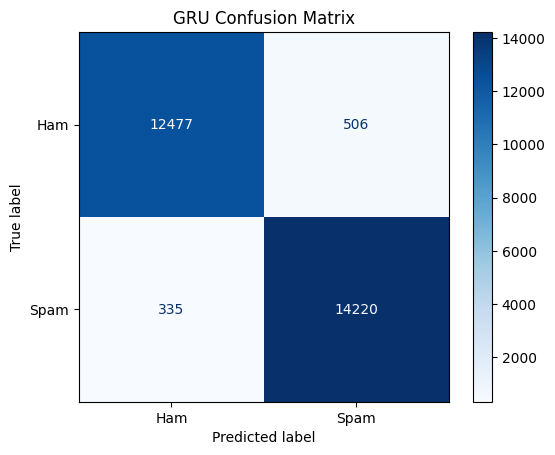

In [31]:
from sklearn.metrics import ConfusionMatrixDisplay
cm_gru = confusion_matrix(y_test, y_pred_gru)

ConfusionMatrixDisplay(
    confusion_matrix=cm_gru,
    display_labels=["Ham","Spam"]
).plot(cmap='Blues')

plt.title("GRU Confusion Matrix")
plt.show()

In [32]:
model_gru.save("gru_model.keras")

In [33]:
import pickle

with open("tokenizer.pickle", "wb") as f:
  pickle.dump(tokenizer, f)

In [34]:
config = {
    "max_feature": max_feature,
    "max_length": max_length,
    "embedding_length": embidding_length
}

with open("config.pkl", "wb") as f:
  pickle.dump(config, f)

In [35]:
label_mapping = {0: "Ham", 1: "Spam"}

with open("label_mapping.pkl", "wb") as f:
  pickle.dump(label_mapping, f)